# Plot AnDi trajectories from phenmenological models

In [1]:
import numpy as np, matplotlib.pyplot as plt, andi_datasets, stochastic

In [4]:
from andi_datasets.models_phenom import models_phenom
from pathlib import Path

In [5]:
def save_plot(fname: str, fig):
    path_fig = Path("../../data/figures/")
    fig.savefig(path_fig/(fname+".pdf"), dpi=300, bbox_inches='tight', pad_inches=0.00);
    fig.savefig(path_fig/(fname+".svg"), bbox_inches='tight');
    print(f'Saved {path_fig/fname}')

In [6]:
# number of time steps per trajectory (frames)
T = 500
# number of trajectories
N = 100
# Length of box (pixels)
L = 1.5*128
# diffusion coefficient (pixels^2 / frame)
D = 0.1
alpha=1.5
trajs_model1, _ = models_phenom().single_state(N = N, L = L, T = T,
                                                Ds = [D, 0.1], # Mean and variance
                                                alphas = alpha,)

In [7]:
trajs_model2, labels_model2 = models_phenom().multi_state(N = N, L = L, T = T,
                                                          alphas = [alpha, 1.25, 1], # Fixed alpha for each state
                                                          Ds = [[10*D, 0.1], [10*D, 0.0], [10*D, 0.0]], # Mean and variance of each state
                                                          M = [[0.985, 0.015, 0.00],
                                                               [0.00, 0.99, 0.01],
                                                               [0.01, 0.00, 0.99]])

In [8]:
i=33
stochastic.random.seed(i); np.random.seed(i)
trajs_model3, labels_model3 = models_phenom().dimerization(N = 2, L = L, T = T,
                                                       alphas = [alpha, 1], # Fixed alpha for each state
                                                       Ds = [10*D, 10*D], # Fixed D for each state
                                                       r = 1, # Radius of the particles
                                                       Pb = 1, # Binding probability
                                                       Pu = 0.05 # Unbinding probability
                                                       )
if (labels_model3[:,:,0]!=1.5).sum()>0: print(i, (labels_model3[:,:,0]!=1.5).sum())

33 76


In [9]:
i=33
stochastic.random.seed(i); np.random.seed(i)
number_compartments = 10
radius_compartments = 20
center_compartments = models_phenom._distribute_circular_compartments(Nc = number_compartments,
                                                                      r  = radius_compartments,
                                                                      L = L # size of the environment
                                                                      )
trajs_model4, labels_model4 = models_phenom().confinement(N = 1, L = L,
                                                          Ds = [500*D, 50*D],
                                                          comp_center = center_compartments,
                                                          r = radius_compartments,
                                                          trans = 0.2 # Boundary transmittance
                                                           )

In [10]:
models_phenom.immobile_traps??

Signature:
models_phenom.immobile_traps(
    self,
    N=10,
    T=200,
    L=100,
    r=1,
    Pu=0.1,
    Pb=0.01,
    Ds=[1, 0],
    alphas=[1, 0],
    Nt=10,
    traps_pos: <built-in function array> = None,
    deltaT=1,
)
Docstring:
Generates a dataset of 2D trajectories of particles diffusing in an environment with immobilizing traps.

Parameters
----------
N : int
    Number of trajectories
T : int
    Length of the trajectory
L : float
    Length of the box acting as the environment
r : float
    Radius of particles.
Pu : float in [0,1]
    Unbinding probability.
Pb : float in [0,1])
    Binding probability.    
Ds : list, float
    Mean and variance from which to sample the diffusion coefficient of the free state. If float, we consider variance = 0
alphas : list, float
    Mean and variance from which to sample the anomalous exponent of the free state. If float, we consider variance = 0
Nt : int
    Number of traps
traps_pos : array, None
    Positions of the traps. Can be giv

In [11]:
i=34
stochastic.random.seed(i); np.random.seed(i)
number_traps = 150
radius_traps = 2
traps_positions = np.random.rand(number_traps, 2)*L
trajs_model5, labels_model5 = models_phenom().immobile_traps(N = 1, T = T, L = L,
                                                             r = radius_traps, # Radius of the traps
                                                             Pu = 0.02, # Unbinding probability
                                                             Pb = 1, # Binding probability
                                                             Ds = 2*D, # Diffusion coefficients of moving state
                                                             alphas = alpha, # Anomalous exponents of moving state
                                                             Nt = number_traps, # Number of traps
                                                             traps_pos = traps_positions
                                                             )

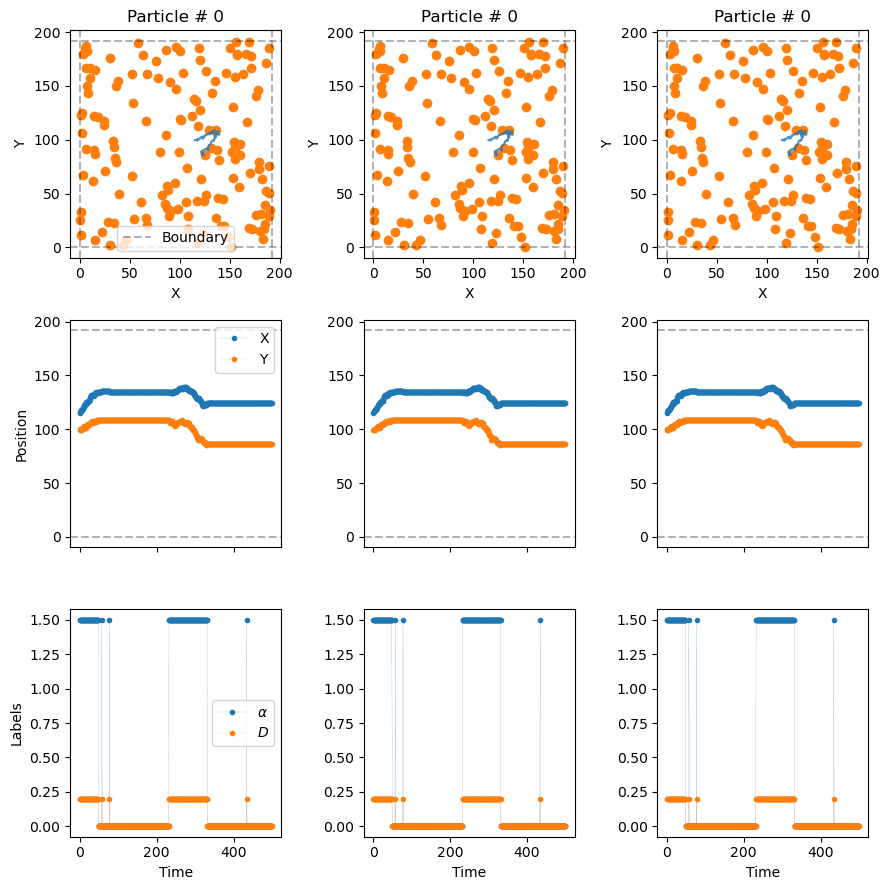

In [13]:
from andi_datasets.utils_trajectories import plot_trajs
plot_trajs(trajs_model5, L, 1,
           labels = labels_model5, plot_labels = True,
           traps_positions = traps_positions)

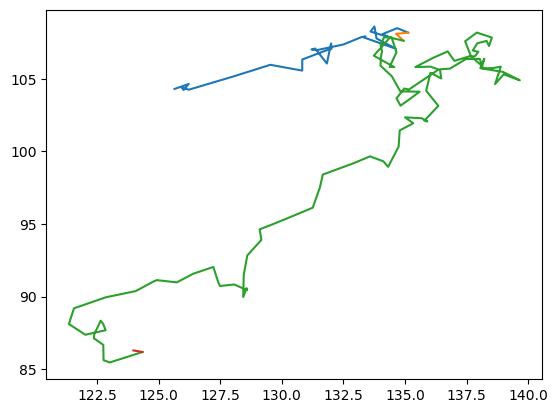

In [14]:
plt.plot(*trajs_model5[20:58,0].T, '-');
plt.plot(*trajs_model5[58:233,0].T, '-');
plt.plot(*trajs_model5[232:332,0].T, '-');
plt.plot(*trajs_model5[332:,0].T, '-');

In [15]:
# np.savez_compressed("../../data/figures/phenom_model_trajs",
#                    trajs_model1=trajs_model1,
#                    trajs_model2=trajs_model2,
#                    trajs_model3=trajs_model3,
#                   trajs_model4=trajs_model4,
#                   trajs_model5=trajs_model5,)

In [16]:
with np.load("../../data/figures/phenom_model_trajs.npz") as f:
    trajs_model1=f['trajs_model1']
    trajs_model2=f['trajs_model2']
    trajs_model3=f['trajs_model3']
    trajs_model4=f['trajs_model4']
    trajs_model5=f['trajs_model5']

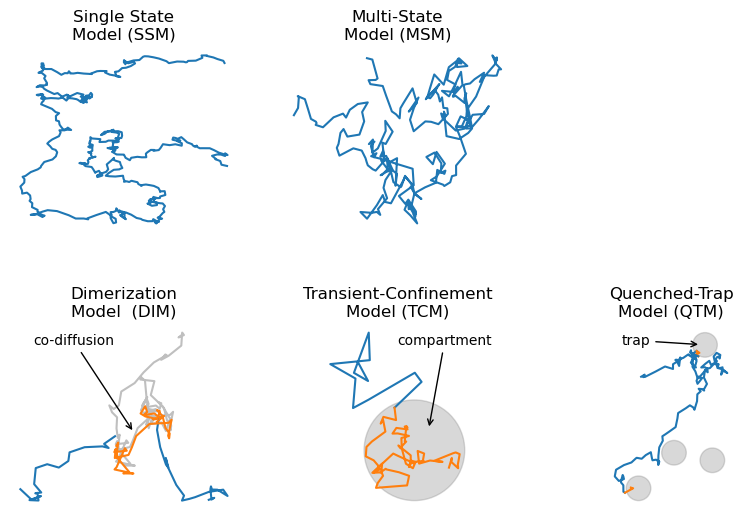

In [17]:
## track = 2

fig,axs = plt.subplots(2,3,figsize=(10,6),
                       gridspec_kw=dict(hspace=0.5, wspace=0.2))
axs = axs.flatten()

axs[2].remove(); axs = np.delete(axs,2)

phenom_models = ['Single State\nModel (SSM)', 'Multi-State\nModel (MSM)',
                 'Dimerization\nModel  (DIM)', 'Transient-Confinement\nModel (TCM)',
                 'Quenched-Trap\nModel (QTM)']
# SSM
axs[0].plot(*trajs_model1[:,2].T, '-');
# MSM
j=8
skip=0
cut = 100
segments = np.concatenate(([0],np.flatnonzero(np.diff(labels_model2[skip:-cut,j,0]))))+skip
mean_traj2 = trajs_model2[:,j].mean(0)
for s,e in zip(segments[:-1],segments[1:]):
    axs[1].plot(*trajs_model2[s:e+1,j].T, '-', c=f'C{int(labels_model2[s+1,j,0]*4%3)}');
    # axs[1].annotate("", xytext=(*mean_traj2,), xy=(*trajs_model2[e,j],),arrowprops=dict(arrowstyle="->"))
    if e!=segments[-1]: axs[1].annotate("time-dependent\nchanges", xytext=(0.5,0.95),
                    textcoords='axes fraction',va='top', ha='left',
                    xy=(*trajs_model2[e,j],),arrowprops=dict(arrowstyle="->",shrinkB=1))

# DIM
# axs[0].plot(*trajs_model1[:,15].T, '-', c='gray',alpha=0.5);
axs[2].plot(*trajs_model3[60:140,0].T, '-',c='gray',alpha=0.5);
segments = np.flatnonzero(np.diff(labels_model3[60:140,0,0]))
axs[2].plot(*trajs_model3[60:60+segments[0],1].T, '-', c='C0');
axs[2].plot(*trajs_model3[60+segments[0]:60+segments[-1],1].T, '-', c='C1');
axs[2].plot(*trajs_model3[60+segments[-1]:140,1].T, '-', c='C0');
axs[2].annotate("co-diffusion", xytext=(0.1,0.95),
                    textcoords='axes fraction',va='top', ha='left',
                    xy=(*trajs_model3[104,1],),arrowprops=dict(arrowstyle="->",shrinkB=5))
# TCM
axs[3].set_aspect('equal')
axs[3].add_patch(plt.Circle(center_compartments[5],radius=radius_compartments,color='gray', alpha=0.3))
axs[3].plot(*trajs_model4[:12,0].T, '-');
axs[3].plot(*trajs_model4[11:80,0].T, '-');
axs[3].annotate("compartment", xytext=(0.5,0.95),
                    textcoords='axes fraction',va='top', ha='left',
                    xy=(*trajs_model4[65,0],),arrowprops=dict(arrowstyle="->",shrinkB=25))
# QTM
axs[4].plot(*trajs_model5[20:56,0].T, '-', c='C0');
axs[4].plot(*trajs_model5[55:233,0].T, '-', c='C1');
axs[4].plot(*trajs_model5[232:331,0].T, '-', c='C0');
axs[4].plot(*trajs_model5[330:,0].T, '-', c='C1');
for i in [58,99,131,10]:
    axs[4].add_patch(plt.Circle(traps_positions[i],radius=radius_traps,color='gray', alpha=0.3))
# for i in range(150):    axs[4].annotate(f'{i}',traps_positions[i])
axs[4].annotate('trap',xytext=(0.1,0.95),
                    textcoords='axes fraction',va='top', ha='left',
                    xy=traps_positions[131],arrowprops=dict(arrowstyle="->",shrinkB=5))
axs[4].set_aspect('equal')
for i,ax in enumerate(axs):
    ax.set_axis_off()
    ax.set_title(phenom_models[i])
# save_plot("phenom_models",fig)

In [45]:
i=31
stochastic.random.seed(i); np.random.seed(i)
trajs, labels = models_phenom().multi_state(N = 1, L = L, T = T,
                                                          alphas = [1, 1., 1], # Fixed alpha for each state
                                                          Ds = [[10*D, 0.0], [5*D, 0.0], [1*D, 0.0]], # Mean and variance of each state
                                                          M = [[0.985, 0.015, 0.00],
                                                               [0.00, 0.99, 0.01],
                                                               [0.01, 0.00, 0.99]])

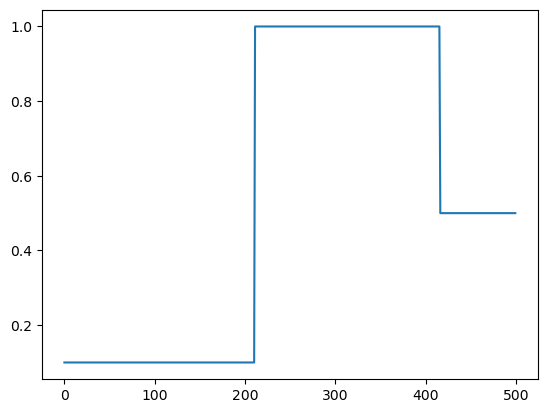

In [46]:
plt.plot(labels[:,0,1]);

In [48]:
np.flatnonzero(np.diff(labels[:,0,1]))

array([210, 415])

Saved ../../data/figures/traj_gray


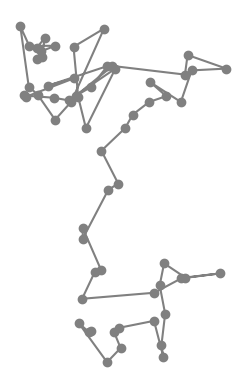

In [124]:
plt.plot(*trajs[190::5,0].T, 'o-',c='gray');
plt.gca().set_axis_off(); plt.gca().set_aspect('equal');
# save_plot("traj_gray", plt.gcf())

Saved ../../data/figures/traj_point


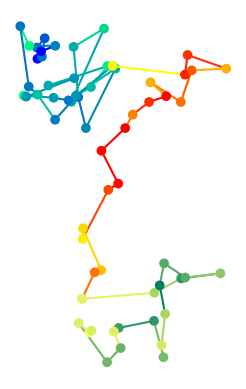

In [125]:
from matplotlib.collections import LineCollection
np.random.seed(i)
t1 = slice(190,325,5)
points = trajs[t1]
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc1 = LineCollection(segments, cmap='winter')
c1 = labels[t1,0,1]+np.random.rand(labels[t1,0,1].shape[0])
lc1.set_array(c1)  # set the colors of each segment
plt.gca().add_collection(lc1);
plt.scatter(*points[:,0].T,c=c1, zorder=2,cmap='winter')

t2 = slice(320,415,5)
points = trajs[t2]
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc2 = LineCollection(segments, cmap='autumn')
c2 = labels[t2,0,1]+np.random.rand(labels[t2,0,1].shape[0])
lc2.set_array(c2)  # set the colors of each segment
plt.gca().add_collection(lc2);
plt.scatter(*points[:,0].T,c=c2, zorder=2, cmap='autumn')

t3 = slice(410,None,5)
points = trajs[t3]
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc3 = LineCollection(segments, cmap='summer')
c3 = labels[t3,0,1]+np.random.rand(labels[t3,0,1].shape[0])
lc3.set_array(c3)  # set the colors of each segment
plt.gca().add_collection(lc3);
plt.scatter(*points[:,0].T,c=c3, zorder=2, cmap='summer')
plt.gca().set_axis_off();
plt.gca().set_aspect('equal')
# save_plot("traj_point", plt.gcf())

Saved ../../data/figures/traj_seg


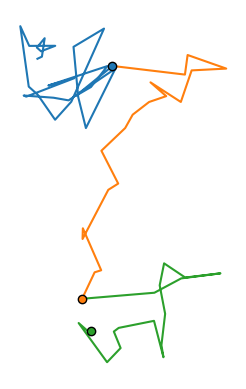

In [142]:
plt.plot(*trajs[t1,0].T, '-');
plt.plot(*trajs[t2,0].T, '-');
plt.plot(*trajs[t3,0].T, '-');
plt.scatter(*trajs[t1,0][-1].T,c='C0',ec='k',lw=1,zorder=2)
plt.scatter(*trajs[t2,0][-1].T,c='C1',ec='k',lw=1,zorder=2)
plt.scatter(*trajs[t3,0][-1].T,c='C2',ec='k',lw=1,zorder=2)
plt.gca().set_axis_off(); plt.gca().set_aspect('equal');
# save_plot("traj_seg", plt.gcf())

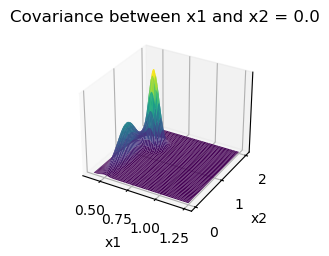

In [341]:
from scipy.stats import multivariate_normal

# Initializing the random seed
random_seed=1000

# first bivariate Gaussian
val = 0.
mean_k_1 = 0.5
mean_a_1 = 0.8
var_k_1 = 0.001
var_a_1 = 0.1
mean = np.array([mean_k_1, mean_a_1])
cov = np.array([[var_k_1, val], [val, var_a_1]])

# Generating a Gaussian bivariate distribution
# with given mean and covariance matrix
distr1 = multivariate_normal(cov = cov, mean = mean,
                            seed = random_seed)

mean_k_2 = 0.6
mean_a_2 = 1.4
var_k_2 = 0.002
var_a_2 = 0.01
mean = np.array([mean_k_2, mean_a_2])
cov = np.array([[var_k_2, val], [val, var_a_2]])
distr2 = multivariate_normal(cov = cov, mean = mean,
                            seed = random_seed)

# x = np.geomspace(1e-12,1e6, num=600)
x = np.geomspace(4e-1,1.25e0, num=1_000)
y = np.linspace(0,2, num=1_000)
X, Y = np.meshgrid(x,y)

# Generating the density function
# for each point in the meshgrid
pdf = np.zeros(X.shape)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        pdf[i,j] += distr1.pdf([X[i,j], Y[i,j]])
        pdf[i,j] += distr2.pdf([X[i,j], Y[i,j]])
ax = plt.subplot(key, projection = '3d')
ax.plot_surface(X, Y, pdf, cmap = 'viridis')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f'Covariance between x1 and x2 = {val}')
ax.axes.zaxis.set_ticks([]); plt.tight_layout()

In [342]:
mu_k_1 = mean_k_1
mu_k_2 = mean_k_2
mu_a_1 = mean_a_1
mu_a_2 = mean_a_2

Saved ../../data/figures/ensemble_params


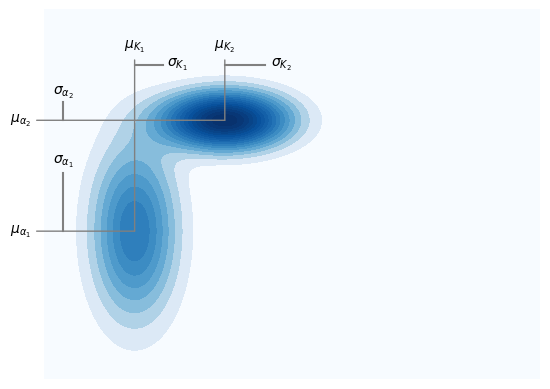

In [343]:
# Plotting contour plots
plt.contourf(X, Y, pdf, 20, cmap='Blues',norm='log')
plt.xlabel(r"$K$");plt.xlim(4e-1,0.95)#1.25e0);#plt.xscale('log')
plt.ylabel(r"$\alpha$");plt.ylim(0,2);

plt.annotate(r'$\mu_{K_1}$',xy=(mu_k_1,mu_a_1),xytext=(mu_k_1,mu_a_2+var_a_2**0.5*4),
             va='center', ha='center',
             arrowprops=dict(arrowstyle="-",color='gray',shrinkB=0))
plt.plot([mu_k_1,mu_k_1+var_k_1**0.5],[mu_a_2+var_a_2**0.5*3]*2, 'gray');
plt.text(s=r'$\sigma_{K_1}$',x=mu_k_1+1.5*var_k_1**0.5,y=mu_a_2+var_a_2**0.5*3,va='center', ha='center',)

plt.annotate(r'$\mu_{K_2}$',xy=(mu_k_2,mu_a_2),xytext=(mu_k_2,mu_a_2+var_a_2**0.5*4),
             va='center', ha='center', arrowprops=dict(arrowstyle="-",color='gray',shrinkB=0))
plt.plot([mu_k_2,mu_k_2+var_k_2**0.5],[mu_a_2+var_a_2**0.5*3]*2, 'gray');
plt.text(s=r'$\sigma_{K_2}$',x=mu_k_2+1.4*var_k_2**0.5,y=mu_a_2+var_a_2**0.5*3,va='center', ha='center',)

plt.annotate(r'$\mu_{\alpha_1}$',xy=(mu_k_1,mu_a_1),xytext=(mu_k_1-var_k_1**.5*4,mu_a_1),
             va='center', ha='center', arrowprops=dict(arrowstyle="-",color='gray',shrinkB=0))
plt.plot([mu_k_1-var_k_1**.5*2.5]*2,[mu_a_1,mu_a_1+var_a_1**0.5], 'gray');
plt.text(s=r'$\sigma_{\alpha_1}$',x=mu_k_1-var_k_1**.5*2.5,y=mu_a_1+var_a_1**0.5*1.2,va='center', ha='center',)

plt.annotate(r'$\mu_{\alpha_2}$',xy=(mu_k_2,mu_a_2),xytext=(mu_k_1-var_k_1**.5*4,mu_a_2),
             va='center', ha='center', arrowprops=dict(arrowstyle="-",color='gray',shrinkB=0))
plt.plot([mu_k_1-var_k_1**.5*2.5]*2,[mu_a_2,mu_a_2+var_a_2**0.5], 'gray');
plt.text(s=r'$\sigma_{\alpha_2}$',x=mu_k_1-var_k_1**.5*2.5,y=mu_a_2+var_a_2**0.5*1.5,va='center', ha='center',);

plt.gca().set_axis_off()
save_plot("ensemble_params", plt.gcf())